(np.float64(-0.5), np.float64(3588.5), np.float64(4640.5), np.float64(-0.5))

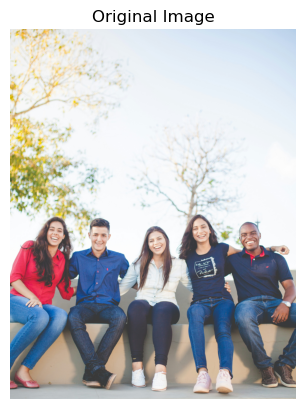

In [11]:
#This is to show original image and ROI cropped region
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('people1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(3288.5), np.float64(3799.5), np.float64(-0.5))

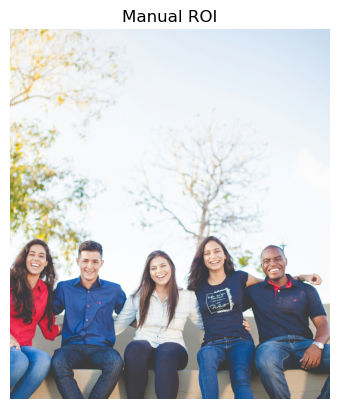

In [13]:
# Define ROI (y1:y2, x1:x2)
#roi = img_rgb[100:300, 200:400]
#roi1 = img_rgb[50:200, 100:300]
roi2 = img_rgb[200:4000, 300:5000]
plt.imshow(roi2)
plt.title("Manual ROI")
plt.axis('off')

(np.float64(-0.5), np.float64(3588.5), np.float64(4640.5), np.float64(-0.5))

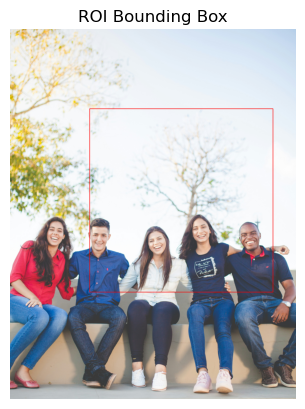

In [32]:
#ROI Using OpenCV
#This phase is very important because the ROI is manual
import cv2

x, y, w, h = 1000, 1000, 2300, 2300 #change the size of the bounding Box
roi2 = img_rgb[y:y+h, x:x+w]

# Draw rectangle
img_copy = img_rgb.copy()
cv2.rectangle(img_copy, (x,y), (x+w,y+h), (255,0,0), 6)

plt.imshow(img_copy)
plt.title("ROI Bounding Box")
plt.axis('off')


image 1/1 /Users/sharifahariffin/anaconda_projects/c3175164-8755-48d9-90d8-85d7ea58f2ed/people1.jpg: 640x512 5 persons, 84.0ms
Speed: 7.3ms preprocess, 84.0ms inference, 10.0ms postprocess per image at shape (1, 3, 640, 512)


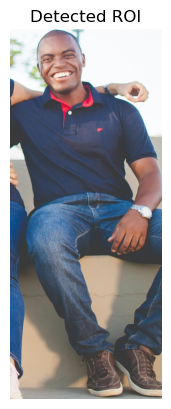

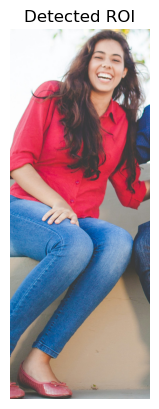

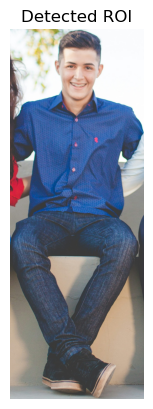

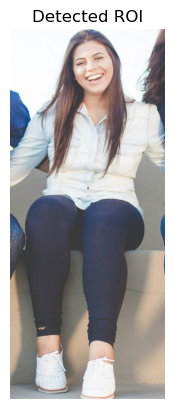

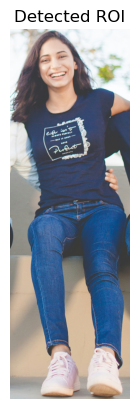

In [34]:
#use YOLO to detect and extract ROI
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model("people1.jpg")

for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        roi2 = img_rgb[y1:y2, x1:x2]
        
        plt.imshow(roi2)
        plt.title("Detected ROI")
        plt.axis('off')
        plt.show()

In [35]:
#ROI for Efficiency
import time
import cv2

# Full image processing
start = time.time()
img = cv2.imread('people1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
end = time.time()
print("Full Image Time:", end - start)

# ROI processing
x, y, w, h = 200, 100, 200, 200
roi2 = img_rgb[y:y+h, x:x+w]
start = time.time()
gray_roi = cv2.cvtColor(roi2, cv2.COLOR_BGR2GRAY)
end = time.time()
print("ROI Time:", end - start)

Full Image Time: 0.15733098983764648
ROI Time: 0.00037288665771484375
